# Bank Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"train.csv\train.csv")

In [3]:
df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [5]:
df.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

##  NO NULL FOUND 

## Columns [  Surname   ,       Geography    ,     Gender    ] are object type

In [6]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [7]:
df2 = df[["id" , "CustomerId" , "Exited"]]

In [8]:
correlation_matrix = df2.corr()

<Axes: >

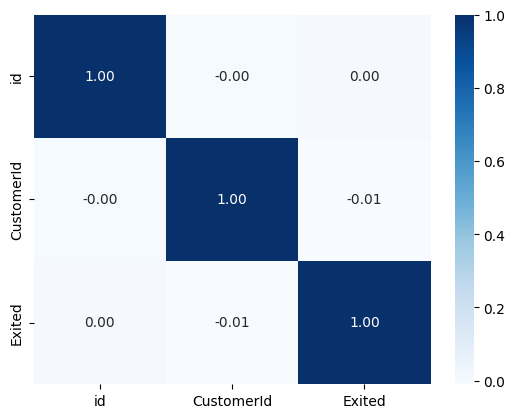

In [9]:
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

### [Surname , id , CustomerId] is not affecting to target so drop them

In [10]:
df.drop(columns=["Surname" , "id" , "CustomerId" ] , inplace=True)

In [11]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...
165029,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


<Axes: xlabel='Geography', ylabel='count'>

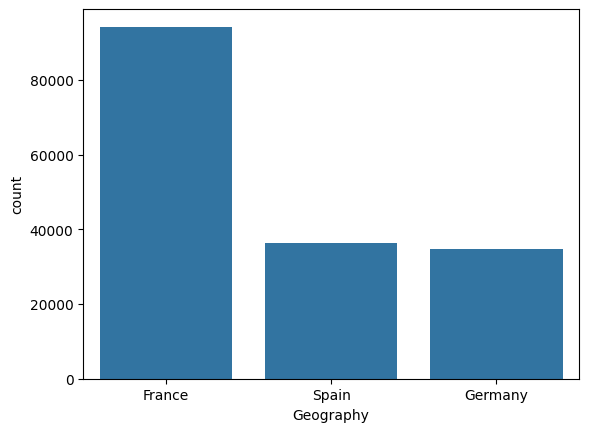

In [12]:
sns.countplot(data=df , x="Geography")

# Encoding Object Columns

In [13]:
df  = pd.get_dummies(df , columns=["Gender" , "Geography"] , drop_first=True , dtype=int )

In [14]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,668,33.0,3,0.00,2,1.0,0.0,181449.97,0,1,0,0
1,627,33.0,1,0.00,2,1.0,1.0,49503.50,0,1,0,0
2,678,40.0,10,0.00,2,1.0,0.0,184866.69,0,1,0,0
3,581,34.0,2,148882.54,1,1.0,1.0,84560.88,0,1,0,0
4,716,33.0,5,0.00,2,1.0,1.0,15068.83,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
165029,667,33.0,2,0.00,1,1.0,1.0,131834.75,0,0,0,1
165030,792,35.0,3,0.00,1,0.0,0.0,131834.45,0,1,0,0
165031,565,31.0,5,0.00,1,1.0,1.0,127429.56,0,1,0,0
165032,554,30.0,7,161533.00,1,0.0,1.0,71173.03,0,0,0,1


## Visiualization

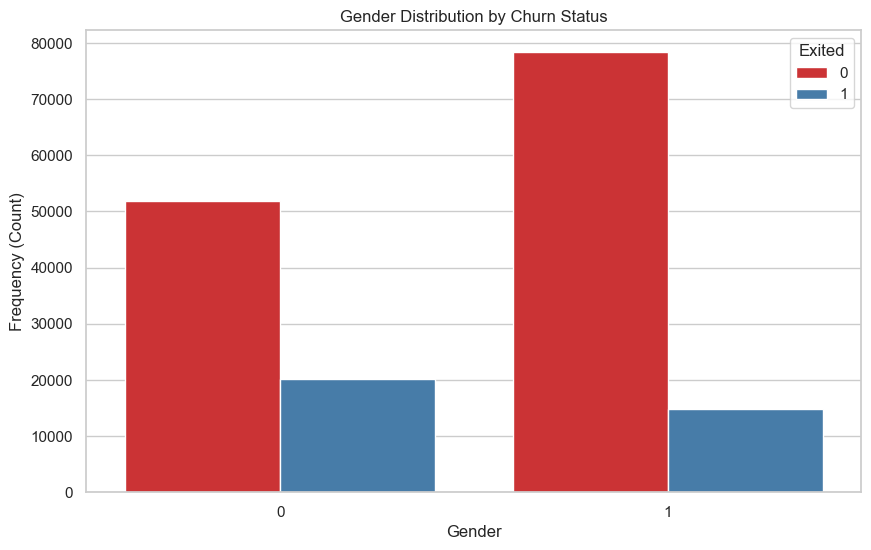

In [15]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender_Male', hue='Exited', palette='Set1')
plt.title('Gender Distribution by Churn Status')
plt.xlabel('Gender')
plt.ylabel('Frequency (Count)')

plt.show()

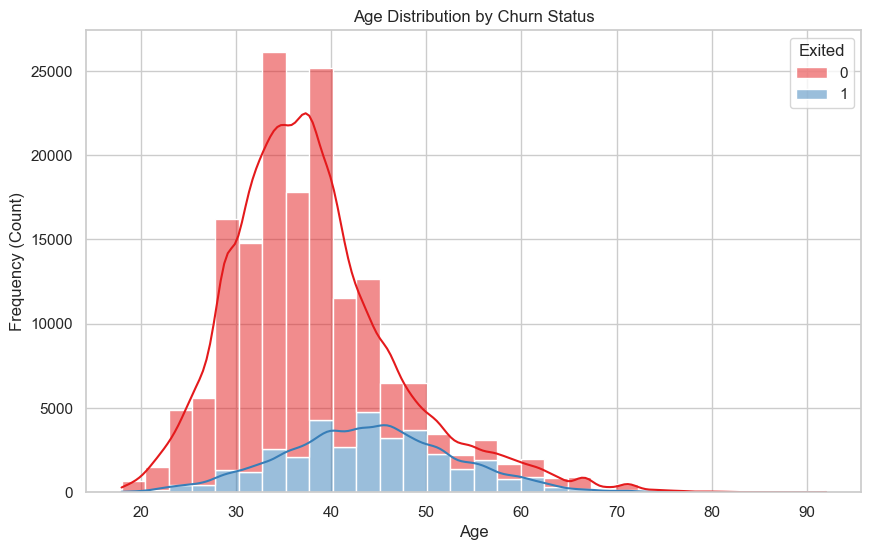

In [16]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette='Set1', multiple='stack')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Frequency (Count)')

plt.show()

In [17]:
correlation_matrix = df.corr()

<Axes: >

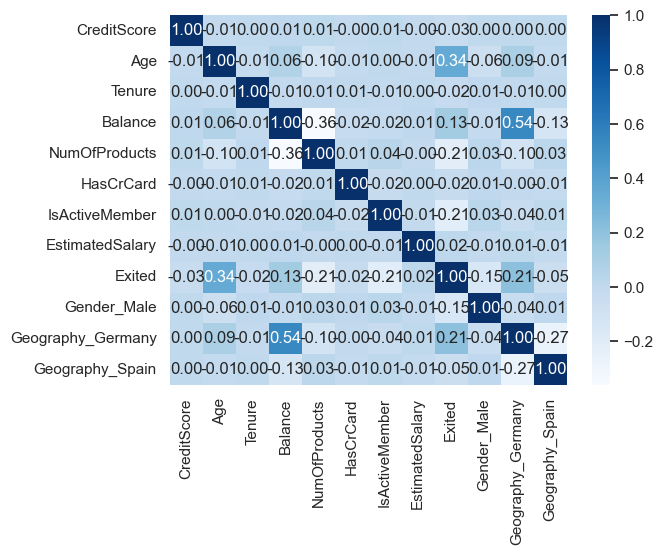

In [18]:
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

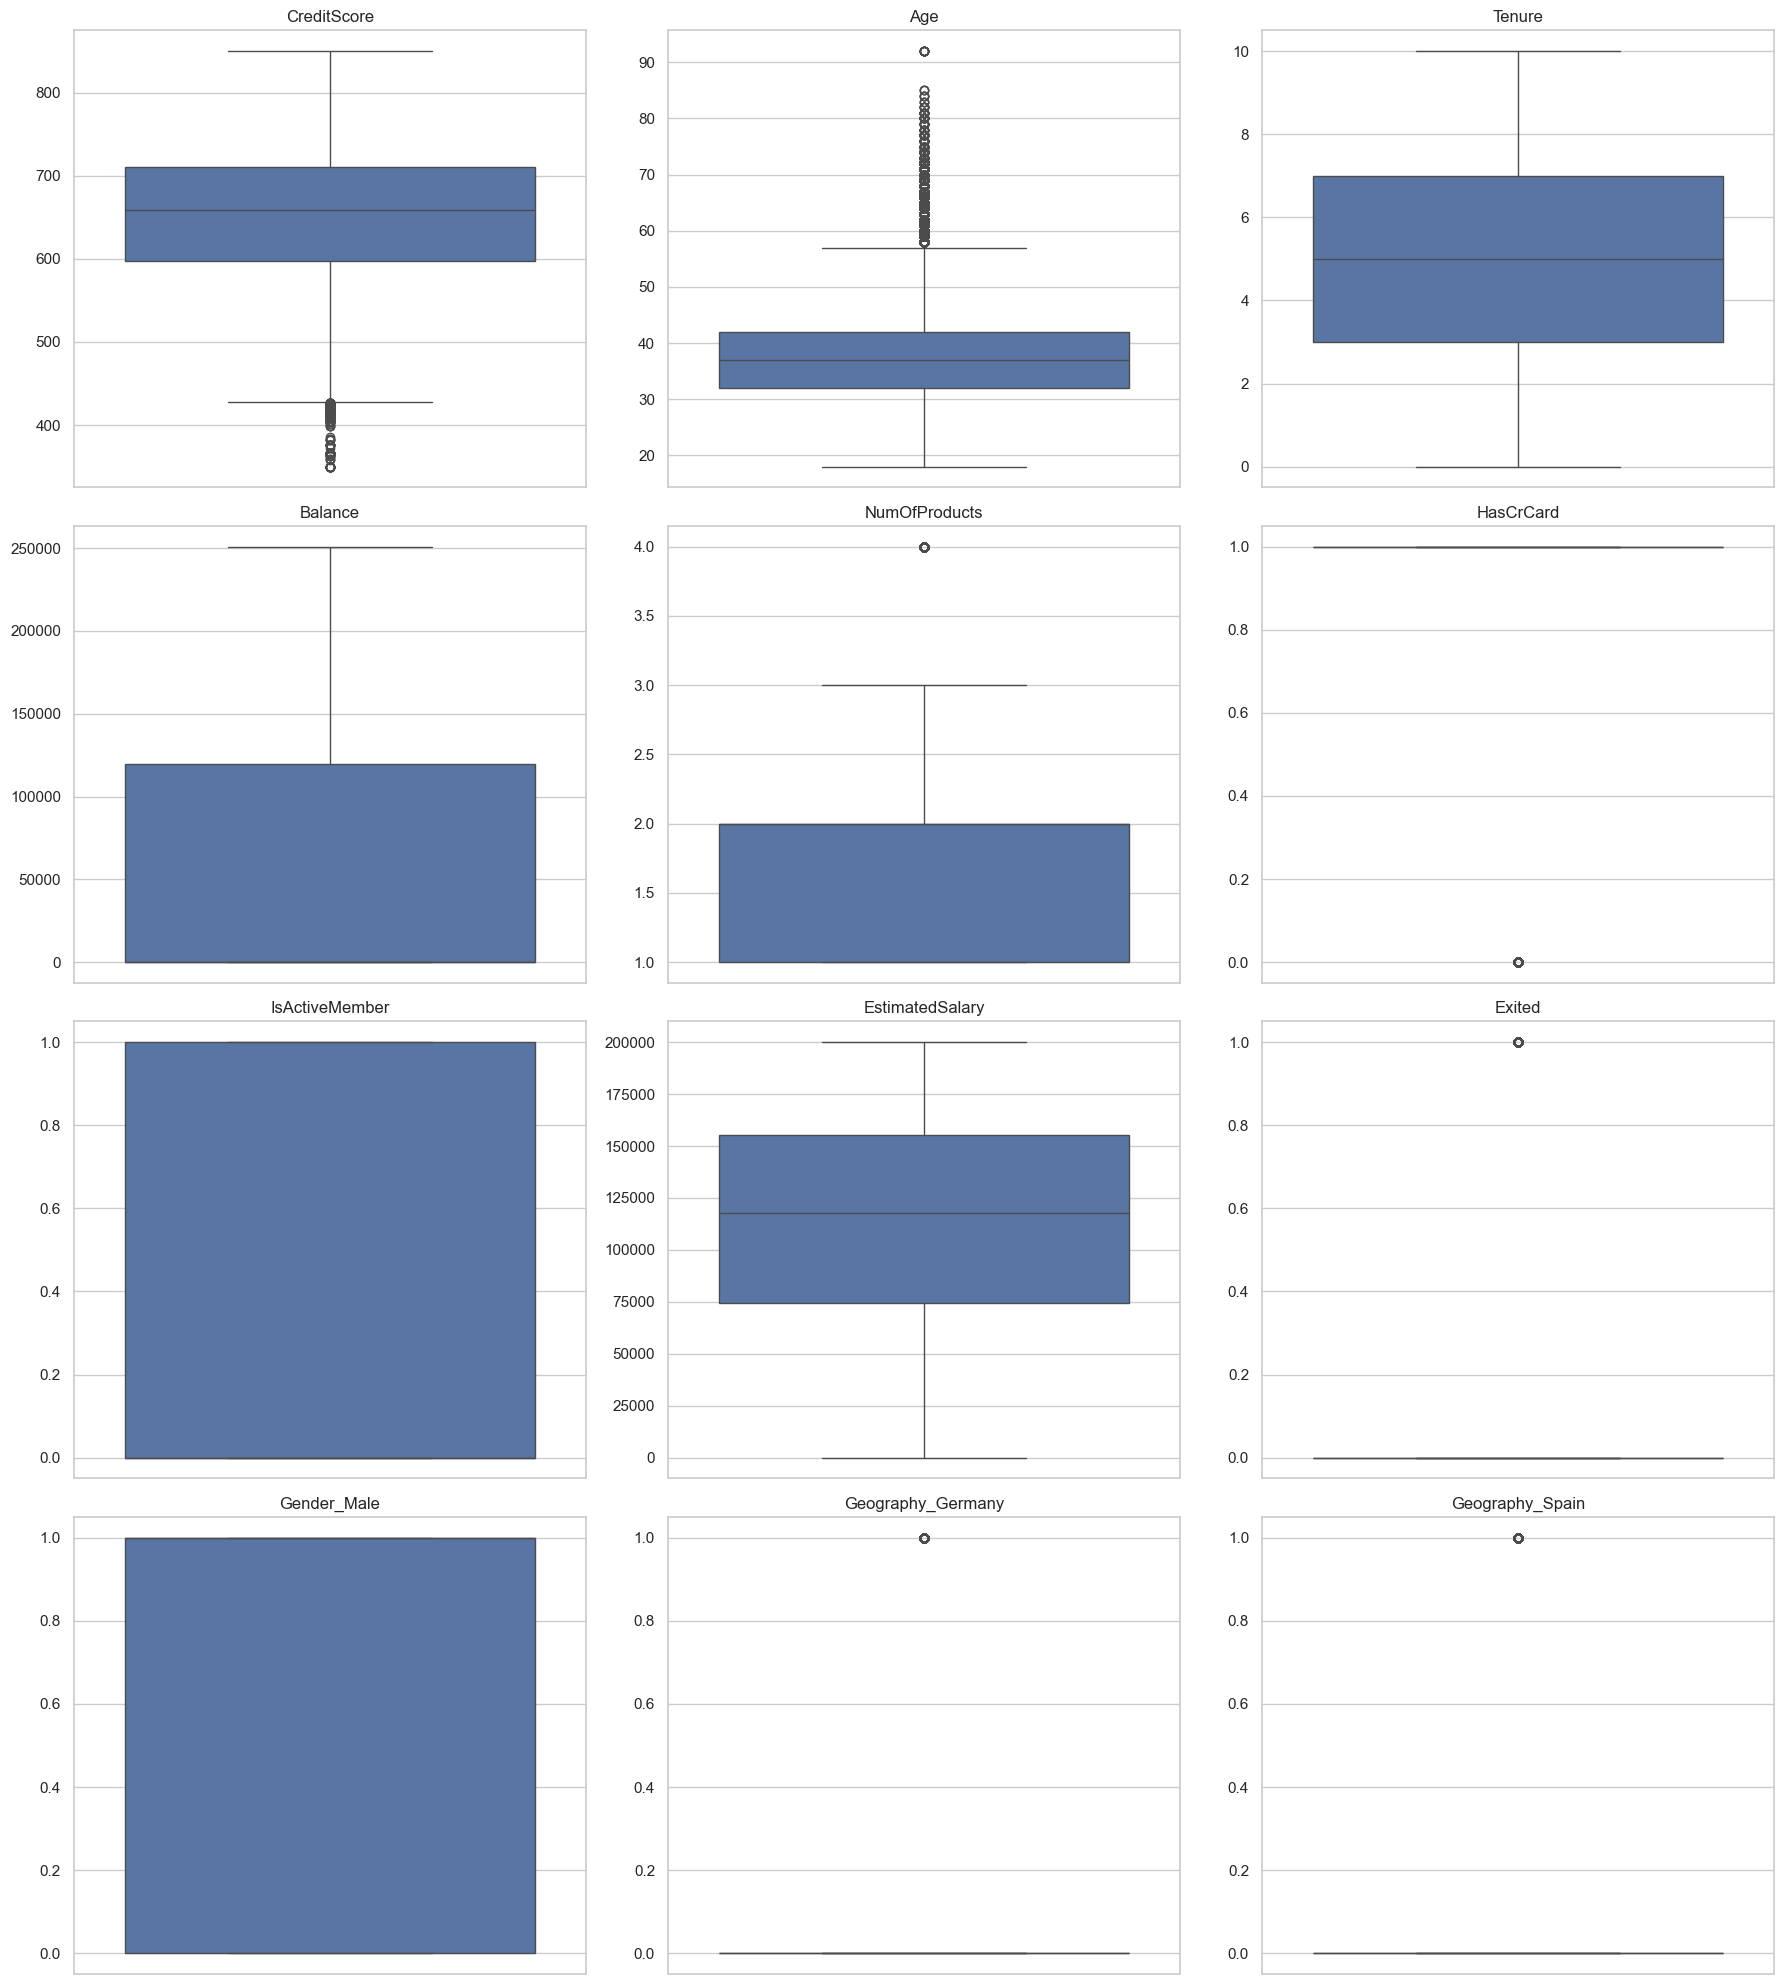

In [19]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Number of columns in the grid
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Draw one boxplot for each feature
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
target = "Exited"

## Drop CreditScore outliers

In [21]:
Q1 = df['CreditScore'].quantile(0.25)
Q3 = df['CreditScore'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['CreditScore'] >= lower) &
    (df['CreditScore'] <= upper)
]

## Scaling (Normalization)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Separate features and target
X = df.drop(target, axis=1)
y = df[target]

# 2. Train-test split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
# 3. Create scaler
scaler = MinMaxScaler()

# 4. Fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# 5. Transform test data using the same scaler
X_test = scaler.transform(X_test)

In [24]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(
   X_train,
   y_train
)

In [25]:
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)

# X_train, y_train = rus.fit_resample(
#     X_train,
#     y_train
# )

<Axes: xlabel='Exited', ylabel='count'>

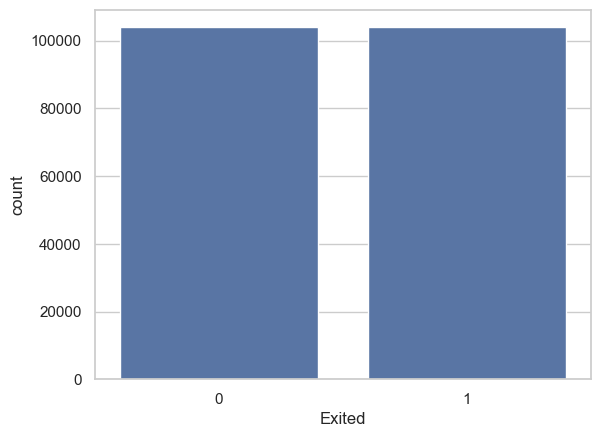

In [26]:
sns.countplot(x=y_train)

# Train models

In [27]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

# Parameters to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [3, 2],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best CV score
print("Best CV Accuracy:", grid_search.best_score_)

# Best model
best_rf = grid_search.best_estimator_

# Test prediction
y_pred = best_rf.predict(X_test)

# Test accuracy

# Full report
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.8562260943158284
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     25990
           1       0.58      0.73      0.65      6967

    accuracy                           0.83     32957
   macro avg       0.75      0.80      0.77     32957
weighted avg       0.85      0.83      0.84     32957



In [28]:
# XGBoost model
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Parameters to test
param_grid = {
    'n_estimators': [250, 200],
    'max_depth': [5, 7, 8],
    'learning_rate': [0.01, 0.04, 0.05],
    'subsample': [0.4, 0.6],
    'colsample_bytree': [0.8, 1.0]
}

# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 250, 'subsample': 0.6}
Accuracy: 0.8606972722031738

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     25990
           1       0.69      0.63      0.66      6967

    accuracy                           0.86     32957
   macro avg       0.79      0.78      0.78     32957
weighted avg       0.86      0.86      0.86     32957


Confusion Matrix:
[[23997  1993]
 [ 2598  4369]]


In [29]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86     25990
           1       0.51      0.80      0.62      6967

    accuracy                           0.79     32957
   macro avg       0.72      0.79      0.74     32957
weighted avg       0.84      0.79      0.81     32957

